# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

# Personal Data:
- Name: Mohammad Choupan
- Student ID: 0001240416
- Email: mohammad.choupan@studio.unibo.it

## GitHub Repository

The project repository is available at [mohamadch91/UNIBO_DL_JIGSAW](https://github.com/mohamadch91/UNIBO_DL_JIGSAW). The training process, experiment changes, and fine-tuning iterations can be followed through the commit history in that repository.


In [ ]:
# Install notebook-only dependencies for experiment tracking and Google Drive downloads.
pip install wandb
pip install gdown


In [1]:
# Import the scientific Python, Keras, Colab, download, plotting, and logging tools used below.
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf
import random
import matplotlib.pyplot as plt
import wandb
from wandb.integration.keras import WandbMetricsLogger
from google.colab import drive
import gdown


In [2]:
# Mount Google Drive so the dataset cache, checkpoints, and final weights persist across Colab sessions.
drive.mount('/content/drive')


Mounted at /content/drive


## Configuration

define a configuration dictionary to hold all the hyperparameters and settings for the training process. This includes paths for data storage, model parameters, training parameters, and any other relevant settings that will be used throughout the code.

### Loading weights via GDOWN (Enabled by default)

- If you want to load weights from a gdown change the value of "load_weights_gdown" to True.
- If you want to load weights from a local file change the value of "load_weights_local" to True and provide the path to the local file in "local_weights_path". Make sure to set "load_weights_gdown" to False if you are loading from a local file to avoid conflicts.
- If you want to train the model from scratch, set both "load_weights_gdown" and "load_weights_local" to False.

### Using Weight and Biases (WandB) for logging (Disabled by default)

- If you want to use WandB for logging, set "use_wandb" to True. This will enable logging of training metrics and other relevant information to your WandB dashboard.

### Use Validation Data for Training (Disabled by default)

- If you want to use the validation data for training, set "include_val_in_final" to True. This will include the validation data in the training process, which can be useful for certain training strategies but may affect the evaluation of the model's performance on unseen data.

In [45]:
# Central configuration for reproducibility, data paths, training, architecture, and output files.
WANDB_USER = ""  # Insert your wandb username here.
WANDB_PROJECT = "DL_JIGSAW"  # Insert your wandb project name here.
WANDB_RUN_NAME = "patches_to_image_spec"  # Insert a descriptive name for this run here.

cfg = {
    # --- Loading Params ---
    "load_weights_local": False,  # Whether to load pre-trained weights from the local Colab/Drive filesystem.
    "load_weights_gdown": False,  # Whether to download pre-trained weights using gdown.
    "drive_path": "/content/drive/MyDrive/stl10_data",  # Path to cache STL-10 data in Google Drive.
    "gdown_id": "1fAa7Ls5L_w57ri9epdkzlJH5lkKd_2j7",  # Google Drive file ID for shared weights.
    "gdown_output_path": "download_jigsaw.weights.h5",  # Local filename for downloaded weights.

    # --- images gdown id ---
    "layer_gdown": "1_BoC_xRcY8ioBg6LD0--rSEasHndM0VE",
    "model_gdown": "1EmEiTd73ke0BojHwK-5RtCii7lukWTEE",

    # --- WandB Params ---
    "use_wandb": False,  # Whether to use Weights & Biases for experiment logging.
    "wandb_user": WANDB_USER,  # Your Weights & Biases username.
    "wandb_project": WANDB_PROJECT,  # Your Weights & Biases project name.
    "wandb_run_name": WANDB_RUN_NAME,  # Display name for the run in the WandB dashboard.

    # ---- Random Seed ---
    "random_seed": 42,  # Set a random seed for reproducibility.

    # --- Training HyperParams ---
    "batch_size": 64,
    "lr": 1e-3,  # Learning rate for the AdamW optimizer.
    "epochs": 130,  # Number of epochs to train for.
    "lr_factor": 0.5,  # Factor used by ReduceLROnPlateau.
    "min_lr": 1e-6,  # Minimum learning rate after reductions.
    "early_stopping_patience": 7,  # Epochs with no validation improvement before stopping.
    "reduce_lr_patience": 4,  # Epochs with no validation improvement before reducing the LR.
    "weight_decay": 5e-4,  # Weight decay for the AdamW optimizer.

    # --- Dataset Params ---
    "train_split": 0.8,  # Proportion of data to use for training.
    "val_split": 0.1,  # Proportion of data to use for validation.
    "test_split": 0.1,  # Proportion of data to use for testing.
    "data_size": 100000,  # Total images to use; set to None to use all available data.

    # --- Architecture Params ---
    "embed_dim": 192,  # Per-patch token size used by the attention mixer.
    "num_heads": 4,  # Number of attention heads in each context mixer block.
    "key_dim": 48,  # Key/query dimension per attention head.
    "mlp_dim": 384,  # Hidden width of the feed-forward mixer.
    "dropout": 0.1,  # Dropout used in attention and token mixing.

    # --- Sinkhorn Params ---
    "sinkhorn_temp": 0.7,  # Temperature applied before iterative normalization.
    "sinkhorn_iters": 20,  # Number of row/column normalization steps.
    "sinkhorn_entropy_weight": 0.003,  # Loss weight encouraging confident assignments.
    "sinkhorn_balance_weight": 0.02,  # Loss weight encouraging one patch per grid cell.

    # --- Patch/Grid Params ---
    "image_size": 96,
    "patch_size": 28,
    "cell_size": 32,
    "margin": 2,

    # --- Validation Params ---
    "include_val_in_final": False,  # Add validation batches for one final fit pass after early stopping.

    # --- Output Params ---
    "output_dir": "/content/drive/MyDrive/jigsaw_outputs",
    "best_weights_filename": "jigsaw_model_best.weights.h5",
    "final_weights_filename": "jigsaw_fmodel_final.weights.h5",
}

# Seed every random source used by the notebook so experiments are easier to reproduce.
random.seed(cfg["random_seed"])
np.random.seed(cfg["random_seed"])
tf.random.set_seed(cfg["random_seed"])


### Setup for loading weights via gdownload

In [46]:
# Helper for retrieving shared checkpoint weights from Google Drive.
def download_gdown(gdown_id):
    """Download a checkpoint file from Google Drive using its file ID.

    Args:
        gdown_id: Google Drive file ID from a shareable checkpoint URL.

    Returns:
        None. The file is downloaded to cfg["gdown_output_path"].
    """
    output_path = cfg["gdown_output_path"]
    print(f"Downloading weights to {output_path}...")
    gdown.download(f"https://drive.google.com/uc?id={gdown_id}", output_path, quiet=False)

    # Verify that the checkpoint file exists before attempting to load it.
    if os.path.exists(output_path):
        print("Download complete! You can now load your weights.")
    else:
        print("Download failed.")


## Dataset
We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [47]:
# Dataset loading and puzzle generation utilities.
def download_and_load_stl10(drive_path):
    """Download, cache, and load the unlabeled STL-10 images.

    Args:
        drive_path: Google Drive directory used as the Keras cache.

    Returns:
        A NumPy array with shape (num_images, 96, 96, 3) and dtype uint8.
    """
    os.makedirs(drive_path, exist_ok=True)

    # Store the archive in Drive so Colab does not need to download it every run.
    filename = "stl10_binary.tar.gz"
    tf.keras.utils.get_file(
        filename,
        origin="http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz",
        cache_dir=drive_path,
        cache_subdir=".",
        extract=True,
    )

    # Keras extracts the tarball below the cache directory. The unlabeled split provides 100k images.
    data_dir = os.path.join(drive_path, "stl10_binary_extracted/stl10_binary")
    filepath = os.path.join(data_dir, "unlabeled_X.bin")

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, "rb") as f:
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))
        images = np.transpose(images, (0, 3, 2, 1))

    return images


class PatchGenerator(PyDataset):
    """Keras dataset that converts full STL-10 images into shuffled 3x3 patch puzzles.

    Each sample returns nine cropped 28x28 patches as the input and the original 96x96
    image as the reconstruction target.
    """

    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        """Store images and generator settings.

        Args:
            images: Array of source images with shape (N, 96, 96, 3).
            batch_size: Number of puzzles produced per batch.
            patch_size: Size of each logical grid cell in the original image.
            crop_size: Center-cropped patch size after erosion.
            shuffle: Whether to shuffle source image order between epochs.
        """
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        """Return the number of batches in one epoch."""
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        """Build one batch of scrambled patches and full-image targets."""
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X has the shuffled patches; Y keeps the corresponding full image target.
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img
            patches = []

            # Extract a 3x3 grid, then center-crop each 32x32 cell to remove border cues.
            for r in range(3):
                for c in range(3):
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[
                        y_start : y_start + self.patch_size,
                        x_start : x_start + self.patch_size,
                        :,
                    ]

                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size, margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Randomize the order so the network must infer placement from visual content.
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        """Shuffle image order after each epoch when requested."""
        if self.shuffle:
            np.random.shuffle(self.indices)


### Downloading the dataset

download the dataset and show its shape and some sample images.


In [6]:
# Download/load STL-10, then optionally truncate it for faster experiments.
images = download_and_load_stl10(cfg["drive_path"])
print(f"Successfully loaded {images.shape[0]} images.")
images = images[:cfg["data_size"]]
print(images.shape)


Loading data from: /content/drive/MyDrive/stl10_data/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.
(100000, 96, 96, 3)


In [7]:
# Split the image array into train, validation, and test partitions according to cfg.
train_images = images[:int(cfg["train_split"] * len(images))]
val_images = images[int(cfg["train_split"] * len(images)):int((cfg["train_split"] + cfg["val_split"]) * len(images))]
test_images = images[int((cfg["train_split"] + cfg["val_split"]) * len(images)):int((cfg["train_split"] + cfg["val_split"] + cfg["test_split"]) * len(images))]
print("Train size is", len(train_images))
print("Val size is", len(val_images))
print("Test size is", len(test_images))


Train size is 80000
Val size is 10000
Test size is 10000


### Generate train,validation,test splits as a generator

In [8]:
# Wrap each split in a generator that creates a fresh random patch order per sample.
train_generator = PatchGenerator(train_images, batch_size=cfg["batch_size"])
val_generator = PatchGenerator(val_images, batch_size=cfg["batch_size"])
test_generator = PatchGenerator(test_images, batch_size=cfg["batch_size"])


Let us inspect the dataset.

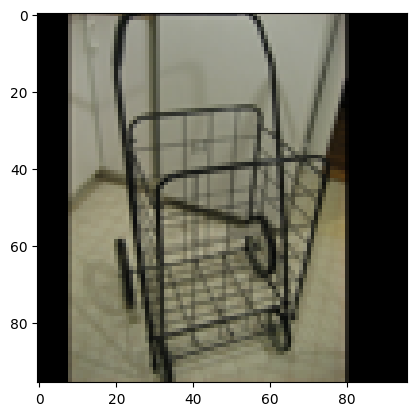

In [9]:
# Display one random source image from the test split before it is converted into puzzle patches.
n = np.random.randint(0, test_images.shape[0])
plt.imshow(test_images[n])


Let us now visualize the puzzle

In [10]:
# Visualization helper for arranging the nine 28x28 patches on the original 96x96 canvas.
import matplotlib.pyplot as plt
import numpy as np


def plot_puzzle(patches, ordering=None):
    """Place jigsaw patches on a 96x96 canvas for visual inspection.

    Args:
        patches: Array of shape (9, 28, 28, 3).
        ordering: Optional destination grid indices. If omitted, patches are shown in input order.

    Returns:
        A 96x96 RGB image containing the patches with blank margins.
    """
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # Use a white canvas for both uint8 and normalized float images.
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    for i in range(9):
        grid_pos = order[i]
        row = grid_pos // 3
        col = grid_pos % 3

        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        canvas[y_start:y_end, x_start:x_end] = patches[i]

    return canvas


In [11]:
# Pull one generated test batch for the following visualization cells.
a, b = test_generator.__getitem__(1)


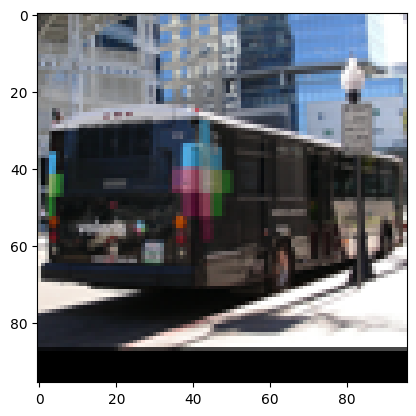

In [12]:
# Show the original target image for one sample in the generated batch.
plt.imshow(b[4])


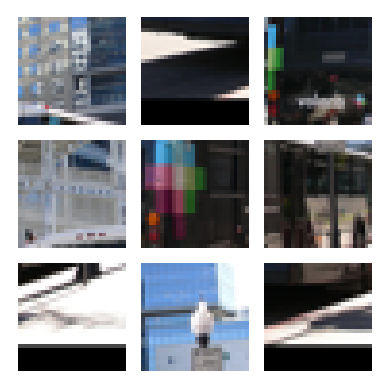

In [13]:
# Show the corresponding scrambled input patches in their current random order.
plt.imshow(plot_puzzle(a[4], ordering=None))
plt.axis("off")
plt.show()


# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [14]:
# Simple baseline: predict every grid cell as the mean of the provided patches.
def mean_patch_image(patches):
    """Create a baseline reconstruction by tiling the average patch.

    Args:
        patches: Tensor with shape (B, 9, 28, 28, 3).

    Returns:
        Tensor with shape (B, 96, 96, 3), resized from a 3x3 mean-patch grid.
    """
    B = tf.shape(patches)[0]
    mean_patch = tf.reduce_mean(patches, axis=1)
    mean_patches = tf.repeat(mean_patch[:, None, :, :, :], repeats=9, axis=1)

    # Reassemble the repeated patches into an 84x84 grid, then resize to the target canvas.
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out


In [15]:
# Compute the mean-patch baseline MAE and its batch-to-batch standard deviation on the test set.
mae_values = []
for i in range(len(test_generator)):
    a, b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(tf.reduce_mean(tf.abs(b - pred)).numpy())

baseline_mae_mean = np.mean(mae_values)
baseline_mae_std = np.std(mae_values)
print(f"Baseline MAE: {baseline_mae_mean:.4f} ± {baseline_mae_std:.4f}")


Baseline MAE: 0.1824 ± 0.0073


### Custom Evaluation Logger

`CustomEvaluationLogger` is an optional Keras callback used when Weights & Biases logging is enabled. At the end of each training epoch, it reads the current training loss and validation loss from Keras, evaluates the model on the test generator, and sends all three MAE values to WandB:

- `Train Set MAE`
- `Validation Set MAE`
- `Test Set MAE`

This makes it easier to compare training, validation, and test reconstruction error across epochs in the WandB dashboard.

In [16]:
# Optional callback for logging test-set MAE at the end of each epoch.
class CustomEvaluationLogger(keras.callbacks.Callback):
    """Evaluate the model on the held-out test generator after each epoch.

    This is intended for experiment tracking. The test metric should be interpreted
    carefully because repeated test monitoring can influence model-selection decisions.
    """

    def __init__(self, test_generator):
        """Store the test generator used for epoch-end evaluation."""
        super().__init__()
        self.test_generator = test_generator

    def on_epoch_end(self, epoch, logs=None):
        """Evaluate and log train, validation, and test MAE after an epoch."""
        logs = logs or {}
        train_mae = logs.get("loss")
        val_mae = logs.get("val_loss")

        print(f"\nEvaluating Test Set at the end of Epoch {epoch + 1}...")
        test_mae = self.model.evaluate(self.test_generator, verbose=0)

        print(f"Epoch {epoch + 1} -> Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | Test MAE: {test_mae:.4f}")

        wandb.log({
            "Train Set MAE": train_mae,
            "Validation Set MAE": val_mae,
            "Test Set MAE": test_mae,
        })


### Final Training Generator

After early stopping selects a strong validation checkpoint, this helper can combine the train and validation splits for one additional training epoch. This gives the final checkpoint access to more data while preserving the separate test split for final reporting.


In [17]:
# Utility generator that exposes two generators as one continuous Keras PyDataset.
class CombinedGenerator(keras.utils.PyDataset):
    """Concatenate two generators without copying their underlying data."""

    def __init__(self, gen1, gen2, **kwargs):
        """Store the two generators that should be traversed in sequence."""
        super().__init__(**kwargs)
        self.gen1 = gen1
        self.gen2 = gen2

    def __len__(self):
        """Return the total number of batches across both generators."""
        return len(self.gen1) + len(self.gen2)

    def __getitem__(self, idx):
        """Return a batch from the first generator, then from the second generator."""
        if idx < len(self.gen1):
            return self.gen1[idx]
        return self.gen2[idx - len(self.gen1)]

    def on_epoch_end(self):
        """Propagate epoch-end shuffling to both child generators."""
        self.gen1.on_epoch_end()
        self.gen2.on_epoch_end()


## Define the Model Layers

The architecture has three main neural stages: patch token encoding, differentiable patch placement, and image repair. The custom layers below keep the placement stage differentiable so the assignment mechanism and repair decoder can be trained together with the MAE reconstruction objective.


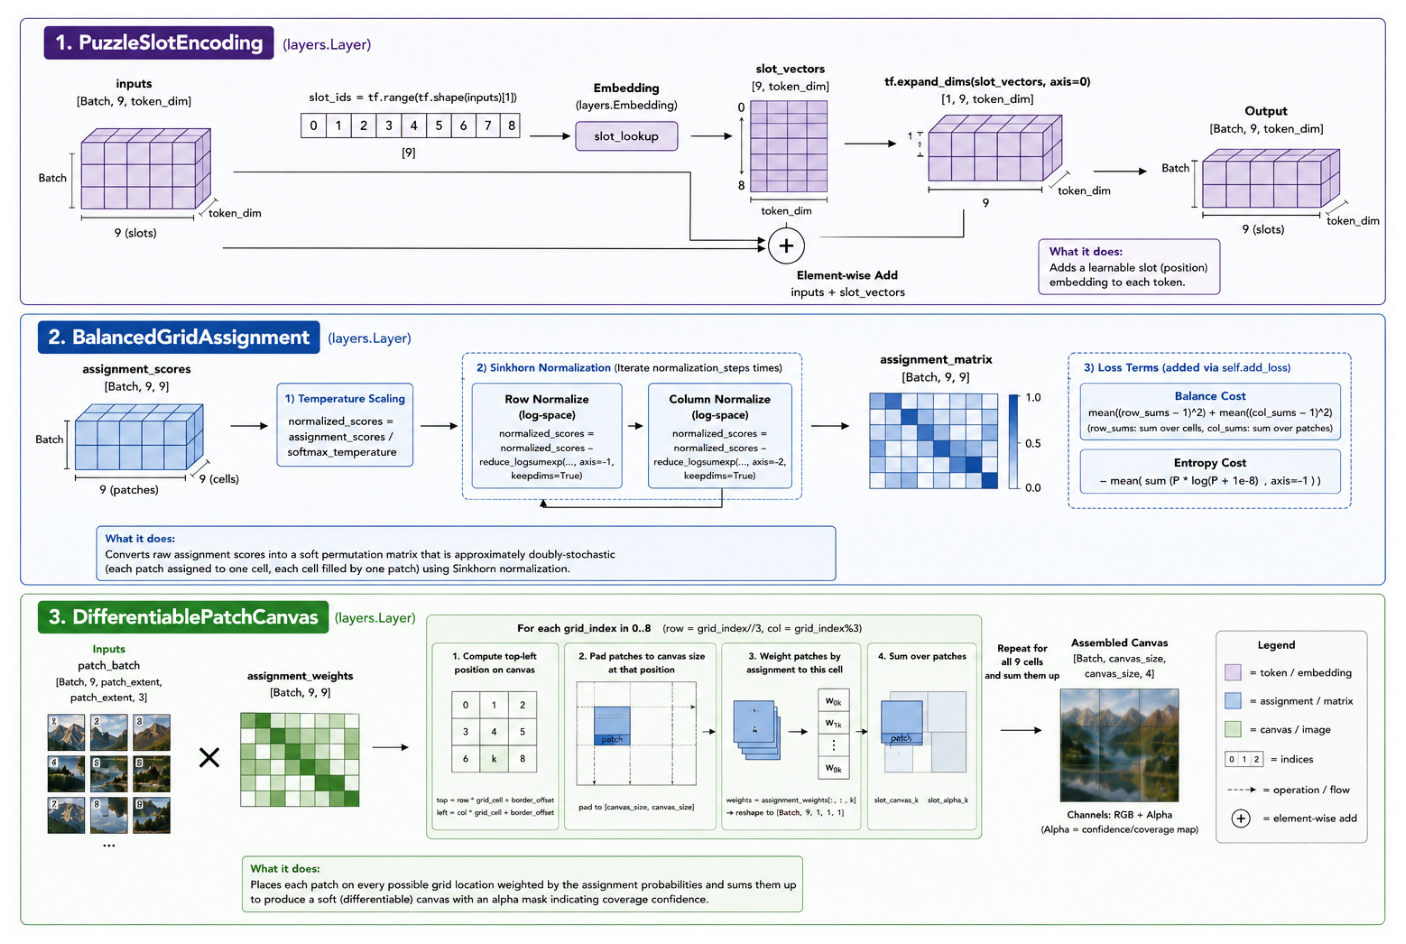

In [18]:
# Display the saved architecture diagram used to explain the layer-level design.
def show_model_image(img_path="dl_layers.png",gdown_id=None):
    """Load and display a local architecture image inside the notebook.

    Args:
        img_path: Path to the image file to display.
        gdown_id: Optional Google Drive file ID used to download the image.


    """
    if gdown is None:
      print("Gdown Id needed")
      return

    gdown.download(f"https://drive.google.com/uc?id={gdown_id}", img_path, quiet=True)

    img = plt.imread(img_path)
    plt.figure(figsize=(20,12))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


show_model_image("dl_layers.png",cfg["layer_gdown"])


### Custom differentiable puzzle-assembly layers
These layers convert encoded patch tokens into a soft 3x3 placement, then render that placement into a differentiable image canvas.

**`@keras.utils.register_keras_serializable()`** lets Keras save and reload each custom layer with the model.

**`PuzzleSlotEncoding(slot_count, token_dim)`**
- Creates a learned embedding table with one vector for each scrambled input slot.
- `tf.range(tf.shape(inputs)[1])` creates slot ids, usually `0..8`.
- `slot_lookup(slot_ids)` converts slot ids into learned slot vectors.
- `tf.expand_dims(..., axis=0)` broadcasts slot vectors across the batch.
- Returns `inputs + slot_vectors`, so each patch token knows which scrambled position it came from.
- `get_config()` saves `slot_count` and `token_dim` for model serialization.

**`BalancedGridAssignment(...)`**
- Receives placement logits with shape `[batch, patches, grid_cells]`.
- Divides logits by `softmax_temperature`; lower temperature makes assignments sharper.
- Repeatedly subtracts `reduce_logsumexp` across rows and columns, approximating Sinkhorn normalization.
- `tf.exp(...)` converts normalized log-scores into a soft assignment matrix.
- `balance_cost` penalizes patch totals and grid-cell totals that differ from `1`.
- `entropy_cost = -sum(p log p)` penalizes uncertain assignments.
- `add_loss(...)` adds these penalties during training, then returns the assignment matrix.

**`DifferentiablePatchCanvas(...)`**
- For each of the 9 grid cells, computes its row/column, padding, and canvas location.
- Pads every patch into that possible cell position on a `96x96` canvas.
- Multiplies padded patches by their assignment weights, then sums across patches.
- Builds RGB plus alpha maps, clips alpha to `[0,1]`, and returns `[batch, 96, 96, 4]`.

In [50]:
# Custom differentiable layers used by the puzzle assembly stage.
@keras.utils.register_keras_serializable()
class PuzzleSlotEncoding(layers.Layer):
    """Add a learned embedding that tells the model which scrambled slot a patch came from."""

    def __init__(self, slot_count, token_dim, **kwargs):
        """Create the slot embedding table."""
        super().__init__(**kwargs)
        self.slot_count = slot_count
        self.token_dim = token_dim
        self.slot_lookup = layers.Embedding(slot_count, token_dim)

    def call(self, inputs):
        """Add one learned slot vector to each patch token."""
        slot_ids = tf.range(tf.shape(inputs)[1])
        slot_vectors = self.slot_lookup(slot_ids)
        return inputs + tf.expand_dims(slot_vectors, axis=0)

    def get_config(self):
        """Return constructor arguments so the layer can be serialized by Keras."""
        config = super().get_config()
        config.update({"slot_count": self.slot_count, "token_dim": self.token_dim})
        return config


@keras.utils.register_keras_serializable()
class BalancedGridAssignment(layers.Layer):
    """Convert placement scores into a balanced soft assignment matrix."""

    def __init__(
        self,
        softmax_temperature=0.7,
        normalization_steps=20,
        entropy_penalty=0.003,
        balance_penalty=0.02,
        **kwargs,
    ):
        """Store Sinkhorn-style normalization and auxiliary-loss settings."""
        super().__init__(**kwargs)
        self.softmax_temperature = softmax_temperature
        self.normalization_steps = normalization_steps
        self.entropy_penalty = entropy_penalty
        self.balance_penalty = balance_penalty

    def call(self, assignment_scores):
        """Normalize logits so each patch and grid cell receive approximately one match."""
        normalized_scores = assignment_scores / self.softmax_temperature

        # Alternating log-space row and column normalization approximates Sinkhorn balancing.
        for _ in range(self.normalization_steps):
            normalized_scores = normalized_scores - tf.reduce_logsumexp(normalized_scores, axis=-1, keepdims=True)
            normalized_scores = normalized_scores - tf.reduce_logsumexp(normalized_scores, axis=-2, keepdims=True)

        assignment_matrix = tf.exp(normalized_scores)
        patch_totals = tf.reduce_sum(assignment_matrix, axis=-1)
        cell_totals = tf.reduce_sum(assignment_matrix, axis=-2)
        balance_cost = tf.reduce_mean(tf.square(patch_totals - 1.0)) + tf.reduce_mean(tf.square(cell_totals - 1.0))
        entropy_cost = -tf.reduce_mean(tf.reduce_sum(assignment_matrix * tf.math.log(assignment_matrix + 1e-8), axis=-1))

        self.add_loss(self.balance_penalty * balance_cost + self.entropy_penalty * entropy_cost)
        return assignment_matrix

    def get_config(self):
        """Return constructor arguments so the layer can be serialized by Keras."""
        config = super().get_config()
        config.update(
            {
                "softmax_temperature": self.softmax_temperature,
                "normalization_steps": self.normalization_steps,
                "entropy_penalty": self.entropy_penalty,
                "balance_penalty": self.balance_penalty,
            }
        )
        return config


@keras.utils.register_keras_serializable()
class DifferentiablePatchCanvas(layers.Layer):
    """Place weighted patches into a 96x96 canvas while preserving gradients."""

    def __init__(self, canvas_size=96, patch_extent=28, grid_cell=32, border_offset=2, **kwargs):
        """Store the canvas geometry used for patch placement."""
        super().__init__(**kwargs)
        self.canvas_size = canvas_size
        self.patch_extent = patch_extent
        self.grid_cell = grid_cell
        self.border_offset = border_offset

    def call(self, inputs):
        """Blend each input patch into each possible grid cell according to assignment weights."""
        patch_batch, assignment_weights = inputs
        patch_batch = tf.cast(patch_batch, assignment_weights.dtype)
        patch_alpha = tf.ones_like(patch_batch[..., :1])

        slot_canvases = []
        slot_alpha_maps = []

        for grid_index in range(9):
            grid_row = grid_index // 3
            grid_col = grid_index % 3
            top = grid_row * self.grid_cell + self.border_offset
            left = grid_col * self.grid_cell + self.border_offset
            bottom = self.canvas_size - top - self.patch_extent
            right = self.canvas_size - left - self.patch_extent
            paddings = [[0, 0], [0, 0], [top, bottom], [left, right], [0, 0]]

            padded_patchs = tf.pad(patch_batch, paddings)
            padded_alpha = tf.pad(patch_alpha, paddings)
            cell_weights = tf.reshape(assignment_weights[:, :, grid_index], [-1, 9, 1, 1, 1])

            slot_canvases.append(tf.reduce_sum(padded_patchs * cell_weights, axis=1))
            slot_alpha_maps.append(tf.reduce_sum(padded_alpha * cell_weights, axis=1))

        assembled_rgb = tf.add_n(slot_canvases)
        assembled_alpha = tf.clip_by_value(tf.add_n(slot_alpha_maps), 0.0, 1.0)
        return tf.concat([assembled_rgb, assembled_alpha], axis=-1)

    def get_config(self):
        """Return constructor arguments so the layer can be serialized by Keras."""
        config = super().get_config()
        config.update(
            {
                "canvas_size": self.canvas_size,
                "patch_extent": self.patch_extent,
                "grid_cell": self.grid_cell,
                "border_offset": self.border_offset,
            }
        )
        return config


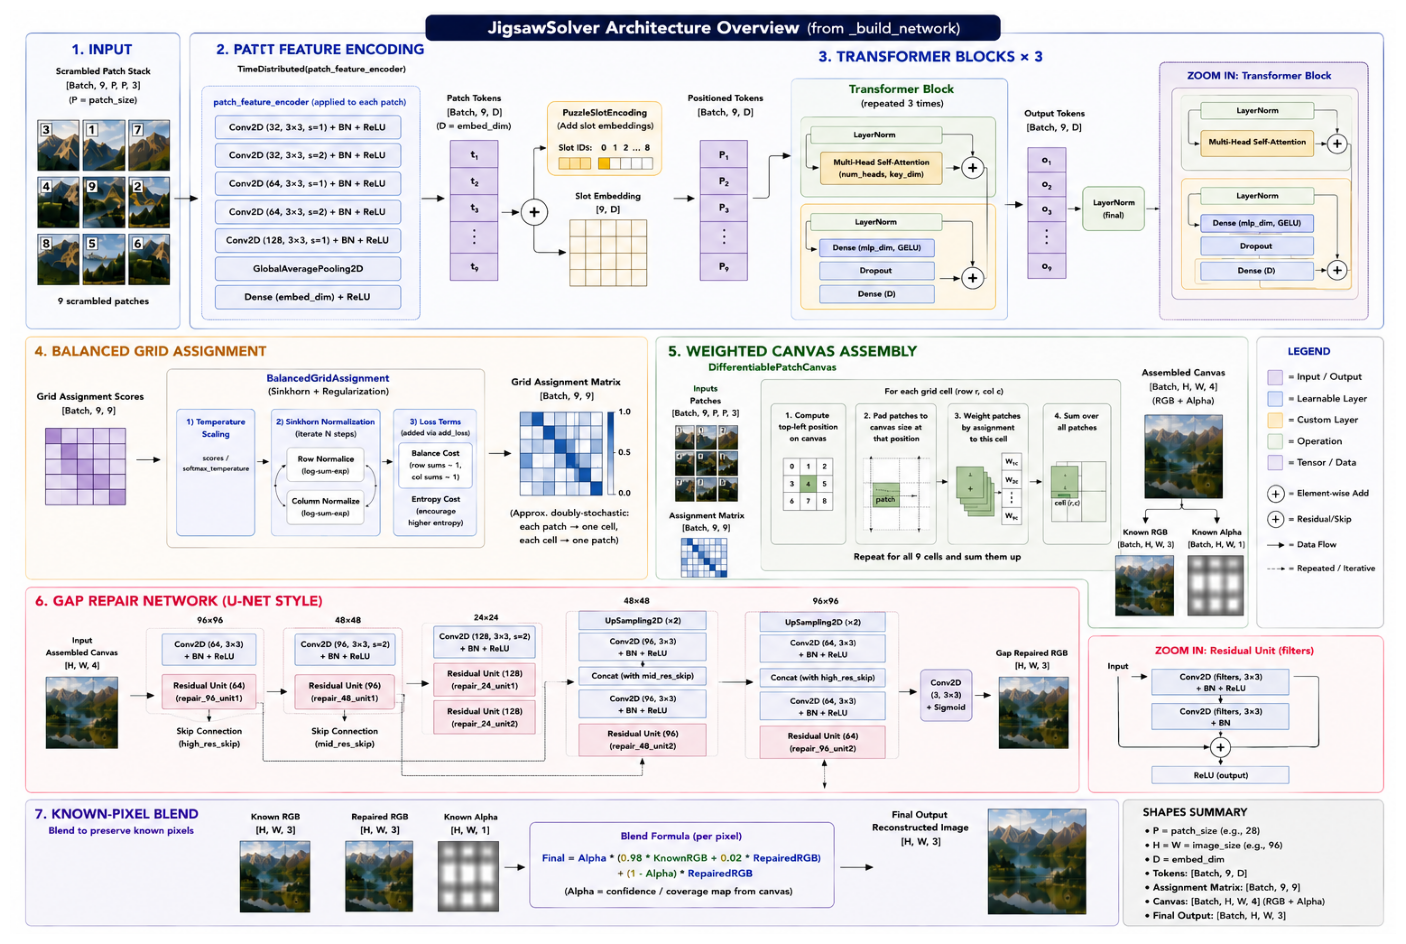

In [51]:
# Display the end-to-end model diagram after the custom assembly layers have been introduced.
show_model_image("dl_model.png",cfg["model_gdown"])


### `JigsawSolver`: end-to-end model wrapper
This class builds the full jigsaw reconstruction network, trains it, loads/saves weights, and reports model size.

- `__init__(cfg)` stores all hyperparameters in `self.cfg` and immediately creates the Keras model with `_build_network()`.
- `_transformer(token_stream, name)` applies one transformer block to the 9 patch tokens.
- It first normalizes tokens, then uses `MultiHeadAttention(query=value=attention_input)` so patches can compare themselves with all other patches.
- The attention output is added back to the original tokens using a residual connection.
- A second normalized MLP block expands token features to `mlp_dim`, applies GELU + dropout, projects back to the original token size, then adds another residual connection.
- `_repair_residual_unit(feature_map, filters, name)` is a CNN residual block: Conv2D -> BatchNorm -> ReLU -> Conv2D -> BatchNorm -> add shortcut -> ReLU.
- `_build_network()` defines input shape `[batch, 9, patch_size, patch_size, 3]`, representing 9 scrambled RGB patches.
- `patch_encoder` is a shared CNN that converts each patch into one `embed_dim` feature vector using convolutions, downsampling, global average pooling, and a dense layer.
- `TimeDistributed(patch_encoder)` applies the same encoder independently to all 9 patches.
- `PuzzleSlotEncoding` adds learned scrambled-position information to each patch token.
- Three transformer blocks let patch tokens exchange global context before placement prediction.
- `Dense(9)` produces placement logits for each patch over the 9 target grid cells, giving a soft 9x9 score matrix.
- `BalancedGridAssignment` turns these scores into a balanced soft assignment matrix where each patch and each grid cell should be used approximately once.
- `DifferentiablePatchCanvas` uses the assignment matrix to place weighted patches into a differentiable `image_size x image_size` RGBA canvas.
- `known_rgb` extracts the assembled RGB channels, while `known_alpha` extracts the mask showing where known patch pixels exist.
- The repair decoder starts from the RGBA canvas and learns to fill gaps or smooth uncertain placements.
- It uses a U-Net-like structure: process at 96x96, downsample to 48x48, downsample to 24x24, then upsample back to 48x48 and 96x96.
- `high_res_skip` and `mid_res_skip` preserve earlier spatial details and are concatenated during upsampling.
- `gap_repaired_rgb` predicts a full repaired RGB image with sigmoid output in the `[0,1]` range.
- `known_pixel_blend` keeps known patch pixels mostly unchanged: `alpha*(0.98*known + 0.02*repaired) + (1-alpha)*repaired`.
- The final Keras model maps scrambled patches directly to the reconstructed image.
- `print_parameter_count()` calculates total and trainable parameters.
- `summary()` prints the Keras model architecture.
- `load_weights(path)` loads saved weights if the checkpoint file exists.
- `fit(...)` optionally starts W&B logging, compiles the model with AdamW and MAE loss, then trains it.
- Training callbacks save the best validation model, reduce learning rate on plateau, and stop early while restoring best weights.
- If `include_val_in_final=True`, the model does one final training epoch on combined train+validation data after model selection.
- Finally, W&B is closed if active, final weights are saved, and the Keras training history is returned.

In [52]:
# End-to-end wrapper that builds, summarizes, loads, trains, and saves the jigsaw model.
class JigsawSolver:
    """Keras-based neural solver for reconstructing STL-10 jigsaw puzzles."""

    def __init__(self, cfg):
        """Store configuration and immediately build the Keras model."""
        self.cfg = cfg
        self.model = self._build_network()

    def _transformer(self, token_stream, name):
        """Apply one transformer-style attention and MLP residual block to patch tokens."""
        attention_input = layers.LayerNormalization(name=f"{name}_attention_norm")(token_stream)
        attn_output = layers.MultiHeadAttention(
            num_heads=self.cfg["num_heads"],
            key_dim=self.cfg["key_dim"],
            dropout=self.cfg["dropout"],
            name=f"{name}_attention",
        )(attention_input, attention_input)
        token_stream = layers.Add(name=f"{name}_attention_residual")([token_stream, attn_output])

        mix_input = layers.LayerNormalization(name=f"{name}_mix_norm")(token_stream)
        mix_output = layers.Dense(self.cfg["mlp_dim"], activation="gelu", name=f"{name}_mix_expand")(mix_input)
        mix_output = layers.Dropout(self.cfg["dropout"], name=f"{name}_mix_dropout")(mix_output)
        mix_output = layers.Dense(token_stream.shape[-1], name=f"{name}_mix_project")(mix_output)
        return layers.Add(name=f"{name}_mix_residual")([token_stream, mix_output])

    def _repair_residual_unit(self, feature_map, filters, name):
        """Apply a two-convolution residual unit inside the repair decoder."""
        shortcut = feature_map
        feature_map = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_first_conv")(feature_map)
        feature_map = layers.BatchNormalization(name=f"{name}_first_norm")(feature_map)
        feature_map = layers.Activation("relu", name=f"{name}_first_relu")(feature_map)
        feature_map = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_second_conv")(feature_map)
        feature_map = layers.BatchNormalization(name=f"{name}_second_norm")(feature_map)
        feature_map = layers.Add(name=f"{name}_residual_merge")([shortcut, feature_map])
        return layers.Activation("relu", name=f"{name}_output_relu")(feature_map)

    def _build_network(self):
        """Construct the full patch encoder, assignment layer, canvas, and repair network."""
        patch_inputs = keras.Input(shape=(9, self.cfg["patch_size"], self.cfg["patch_size"], 3), name="scrambled_patch_stack")

        # Encode each 28x28 patch into one compact token using a shared CNN.
        patch_encoder = keras.Sequential(
            [
                keras.Input(shape=(self.cfg["patch_size"], self.cfg["patch_size"], 3)),
                layers.Conv2D(32, 3, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(64, 3, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(64, 3, strides=2, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(128, 3, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.GlobalAveragePooling2D(),
                layers.Dense(self.cfg["embed_dim"], activation="relu"),
            ],
            name="patch_feature_encoder",
        )

        patch_tokens = layers.TimeDistributed(patch_encoder, name="encode_patch_stack")(patch_inputs)
        patch_tokens = PuzzleSlotEncoding(9, self.cfg["embed_dim"], name="scramble_slot_codes")(patch_tokens)

        # Let patch tokens exchange global context before predicting their grid locations.
        for block_idx in range(3):
            patch_tokens = self._transformer(patch_tokens, name=f"patch_transformer_{block_idx + 1}")

        patch_tokens = layers.LayerNormalization(name="patch_transformer_norm")(patch_tokens)

        # Predict a soft 9x9 matrix: input patch slot by destination grid cell.
        grid_scores = layers.Dense(9, name="grid_assignment_scores")(patch_tokens)
        grid_assignment = BalancedGridAssignment(
            softmax_temperature=self.cfg["sinkhorn_temp"],
            normalization_steps=self.cfg["sinkhorn_iters"],
            entropy_penalty=self.cfg["sinkhorn_entropy_weight"],
            balance_penalty=self.cfg["sinkhorn_balance_weight"],
            name="grid_assignment_matrix",
        )(grid_scores)

        # Assemble a differentiable canvas and alpha mask from the soft placement matrix.
        assembled_canvas = DifferentiablePatchCanvas(
            canvas_size=self.cfg["image_size"],
            patch_extent=self.cfg["patch_size"],
            grid_cell=self.cfg["cell_size"],
            border_offset=self.cfg["margin"],
            name="weighted_patch_canvas",
        )([patch_inputs, grid_assignment])

        known_rgb = layers.Lambda(lambda t: t[..., :3], name="assembled_known_rgb")(assembled_canvas)
        known_alpha = layers.Lambda(lambda t: t[..., 3:4], name="assembled_known_alpha")(assembled_canvas)

        # Repair network: a small encoder-decoder fills eroded gaps and smooths uncertain placement.
        feature_map = layers.Conv2D(64, 3, padding="same", use_bias=False, name="repair_input_conv")(assembled_canvas)
        feature_map = layers.BatchNormalization(name="repair_input_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_input_relu")(feature_map)
        feature_map = self._repair_residual_unit(feature_map, 64, "repair_96_unit1")
        feature_map = self._repair_residual_unit(feature_map, 64, "repair_96_unit1b")
        high_res_skip = feature_map

        feature_map = layers.Conv2D(96, 3, strides=2, padding="same", use_bias=False, name="repair_downsample_48_conv")(feature_map)
        feature_map = layers.BatchNormalization(name="repair_downsample_48_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_downsample_48_relu")(feature_map)
        feature_map = self._repair_residual_unit(feature_map, 96, "repair_48_unit1")
        feature_map = self._repair_residual_unit(feature_map, 96, "repair_48_unit1b")

        mid_res_skip = feature_map

        feature_map = layers.Conv2D(128, 3, strides=2, padding="same", use_bias=False, name="repair_downsample_24_conv")(feature_map)
        feature_map = layers.BatchNormalization(name="repair_downsample_24_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_downsample_24_relu")(feature_map)
        feature_map = self._repair_residual_unit(feature_map, 128, "repair_24_unit1")
        feature_map = self._repair_residual_unit(feature_map, 128, "repair_24_unit2")

        feature_map = layers.UpSampling2D(name="repair_upsample_48")(feature_map)
        feature_map = layers.Conv2D(96, 3, padding="same", use_bias=False, name="repair_upsample_48_conv")(feature_map)
        feature_map = layers.BatchNormalization(name="repair_upsample_48_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_upsample_48_relu")(feature_map)
        feature_map = layers.Concatenate(name="repair_merge_48")([feature_map, mid_res_skip])
        feature_map = layers.Conv2D(96, 3, padding="same", use_bias=False, name="repair_merge_48_conv")(feature_map)
        feature_map = layers.BatchNormalization(name="repair_merge_48_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_merge_48_relu")(feature_map)
        feature_map = self._repair_residual_unit(feature_map, 96, "repair_48_unit2")

        feature_map = layers.UpSampling2D(name="repair_upsample_96")(feature_map)
        feature_map = layers.Conv2D(64, 3, padding="same", use_bias=False, name="repair_upsample_96_conv")(feature_map)
        feature_map = layers.BatchNormalization(name="repair_upsample_96_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_upsample_96_relu")(feature_map)
        feature_map = layers.Concatenate(name="repair_merge_96")([feature_map, high_res_skip])
        feature_map = layers.Conv2D(64, 3, padding="same", use_bias=False, name="repair_merge_96_conv")(feature_map)
        feature_map = layers.BatchNormalization(name="repair_merge_96_norm")(feature_map)
        feature_map = layers.Activation("relu", name="repair_merge_96_relu")(feature_map)
        feature_map = self._repair_residual_unit(feature_map, 64, "repair_96_unit2")

        repaired_rgb = layers.Conv2D(3, 3, padding="same", activation="sigmoid", name="gap_repaired_rgb")(feature_map)

        # Preserve known patch pixels strongly and use the decoder mainly for gaps/uncertain regions.
        final_image = layers.Lambda(
            lambda values: values[2] * (0.98 * values[0] + 0.02 * values[1]) + (1.0 - values[2]) * values[1],
            name="known_pixel_blend",
        )([known_rgb, repaired_rgb, known_alpha])

        return keras.Model(inputs=patch_inputs, outputs=final_image, name="jigsaw_solver_network")

    def print_parameter_count(self, printable=True):
        """Return and optionally print total/trainable parameter counts."""
        trainable_params = int(sum(np.prod(weight.shape) for weight in self.model.trainable_weights))
        total_params = self.model.count_params()
        if printable:
            print("Total parameters:", f"{total_params:,}")
            print("Trainable parameters:", f"{trainable_params:,}")
        return total_params, trainable_params

    def summary(self):
        """Print the Keras model summary."""
        self.model.summary()

    def load_weights(self, path):
        """Load checkpoint weights if the given path exists."""
        if os.path.exists(path):
            print(f"Loading weights from {path}...")
            self.model.load_weights(path)
        else:
            print(f"No checkpoint found at {path}. Starting training from scratch.")

    def fit(self, train_generator, val_generator):
        """Compile and train the model, then save the final checkpoint."""
        if self.cfg["use_wandb"]:
            wandb.init(
                project=self.cfg["wandb_project"],
                name=self.cfg["wandb_run_name"],
                config=self.cfg,
            )
            callbacks = [WandbMetricsLogger(log_freq="epoch"), CustomEvaluationLogger(test_generator)]
        else:
            callbacks = []

        monitor_metric = "val_mae"

        self.model.compile(
            optimizer=keras.optimizers.AdamW(learning_rate=self.cfg["lr"], weight_decay=self.cfg["weight_decay"]),
            loss="mae",
            metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
        )

        best_weights_path = os.path.join(self.cfg["output_dir"], self.cfg["best_weights_filename"])
        final_weights_path = os.path.join(self.cfg["output_dir"], self.cfg["final_weights_filename"])

        callbacks = callbacks + [
            keras.callbacks.ModelCheckpoint(
                filepath=best_weights_path,
                monitor=monitor_metric,
                save_best_only=True,
                save_weights_only=True,
                verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor=monitor_metric,
                factor=self.cfg["lr_factor"],
                patience=self.cfg["reduce_lr_patience"],
                min_lr=self.cfg["min_lr"],
                verbose=1,
            ),
            keras.callbacks.EarlyStopping(
                monitor=monitor_metric,
                patience=self.cfg["early_stopping_patience"],
                verbose=1,
                restore_best_weights=True,
            ),
        ]

        history = self.model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=self.cfg["epochs"],
            callbacks=callbacks,
        )

        # Optional final pass uses validation images for training after model selection is complete.
        if self.cfg["include_val_in_final"]:
            combined_gen = CombinedGenerator(train_generator, val_generator)
            if self.cfg["use_wandb"]:
                callbacks = [WandbMetricsLogger(log_freq="epoch"), CustomEvaluationLogger(test_generator)]
            else:
                callbacks = []
            self.model.fit(
                combined_gen,
                epochs=1,
                callbacks=callbacks,
            )

        if self.cfg["use_wandb"]:
            wandb.finish()

        self.model.save_weights(final_weights_path)
        print("Saved final weights to:", final_weights_path)

        return history


## Run Training or Load Weights

This cell creates the solver, prints the parameter summary, and then chooses one of three paths: load local weights, download weights with gdown, or train from scratch. The final evaluation cells can be run after any of these paths as long as `solver` contains loaded or trained weights.


In [ ]:
# Build the solver and either load existing weights or train the model from scratch.
solver = JigsawSolver(cfg)
solver.summary()

if cfg["load_weights_local"]:
    solver.load_weights(os.path.join(cfg["output_dir"], cfg["best_weights_filename"]))
elif cfg["load_weights_gdown"]:
    download_gdown(cfg["gdown_id"])
    solver.load_weights(cfg["gdown_output_path"])
else:
    print("Start Training without weights")
    history = solver.fit(train_generator, val_generator)


Model: "jigsaw_solver_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ scrambled_patch_st… │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encode_patch_stack  │ (None, 9, 192)    │    165,152 │ scrambled_patch_… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scramble_slot_codes │ (None, 9, 192)    │      1,728 │ encode_patch_sta… │
│ (PuzzleSlotEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ scramble_slot_co… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ scramble_slot_co… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │     73,920 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme

 Total params: 2,952,492 (11.26 MB)

 Trainable params: 2,947,692 (11.24 MB)

 Non-trainable params: 4,800 (18.75 KB)

Start Training without weights
Epoch 1/130
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.1382 - mae: 0.1343
Epoch 1: val_mae improved from None to 0.10756, saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_model_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_model_best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 196s 102ms/step - loss: 0.1248 - mae: 0.1217 - val_loss: 0.1099 - val_mae: 0.1076 - learning_rate: 0.0010
Epoch 2/130
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.1080 - mae: 0.1059
Epoch 2: val_mae improved from 0.10756 to 0.10381, saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_model_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_model_best.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 109s 87ms/step - loss: 0.1060 - mae: 0.1040 - val_loss: 0.1057 - val_mae: 0.1038 - learning_rate: 0.0010
Epoch 3/130
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step -

## Evaluation

The evaluation step computes the assignment metric requested by the problem statement: mean absolute error over the held-out test generator, plus the standard deviation of per-batch MAE values.


In [27]:
# Final metric helper for computing test reconstruction error and its batch variability.
def evaluate_and_get_metrics(solver, generator):
    """Evaluate a solver/model on a generator and return test MAE statistics.

    Args:
        solver: A JigsawSolver instance or compiled Keras model.
        generator: A Keras-compatible generator yielding (patches, target_image).

    Returns:
        Tuple of (test_mae, test_mae_batch_std) across generator batches.
    """
    model = solver.model if hasattr(solver, "model") else solver
    batch_mae_scores = []

    for i in range(len(generator)):
        x_batch, y_true_img = generator[i]
        y_pred_img = model(x_batch, training=False)

        batch_mae = tf.reduce_mean(tf.abs(y_true_img - y_pred_img)).numpy()
        batch_mae_scores.append(batch_mae)

    test_mae = np.mean(batch_mae_scores)
    test_mae_batch_std = np.std(batch_mae_scores)

    return test_mae, test_mae_batch_std


# Run the final held-out test evaluation and print the required metrics.
test_mae, test_mae_batch_std = evaluate_and_get_metrics(solver, test_generator)

print("\n" + "=" * 48)
print(" " * 14 + "FINAL TEST EVALUATION")
print("=" * 48)
print(f"{'Test MAE':<28}: {test_mae:>10.4f}")
print(f"{'Batch-to-batch std':<28}: {test_mae_batch_std:>10.4f}")
print("=" * 48)


              FINAL TEST EVALUATION
Test MAE                    :     0.0680
Batch-to-batch std          :     0.0073


In [28]:
xxxx = JigsawSolver(cfg)
download_gdown(cfg["gdown_id"])
xxxx.load_weights(cfg["gdown_output_path"])
xxxx.summary()


test_mae, test_mae_batch_std = evaluate_and_get_metrics(xxxx, test_generator)

print("\n" + "=" * 48)
print(" " * 14 + "FINAL TEST EVALUATION")
print("=" * 48)
print(f"{'Test MAE':<28}: {test_mae:>10.4f}")
print(f"{'Batch-to-batch std':<28}: {test_mae_batch_std:>10.4f}")
print("=" * 48)

Loading weights from /content/drive/MyDrive/jigsaw_outputs/jigsaw_fmodel_best_struct.weights.h5...


Model: "jigsaw_solver_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ scrambled_patch_st… │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encode_patch_stack  │ (None, 9, 192)    │    165,152 │ scrambled_patch_… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scramble_slot_codes │ (None, 9, 192)    │      1,728 │ encode_patch_sta… │
│ (PuzzleSlotEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ scramble_slot_co… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ scramble_slot_co… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │     73,920 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme

 Total params: 2,952,492 (11.26 MB)

 Trainable params: 2,947,692 (11.24 MB)

 Non-trainable params: 4,800 (18.75 KB)

KeyboardInterrupt: 

### Visualize Results

The following helper compares the scrambled input layout, the ground-truth image, the reconstructed output, and the absolute error map. This is useful for checking whether the model is learning both patch placement and border repair rather than only improving the scalar MAE.


In [ ]:
# Qualitative visualization helper for reconstructed test samples.
def visualize_random_predictions(solver, generator, num_samples=3):
    """Show scrambled patches, target image, prediction, and absolute error.

    Args:
        solver: A JigsawSolver instance or compatible Keras model.
        generator: Dataset generator used to draw random samples.
        num_samples: Number of examples to visualize from one random batch.
    """
    model = solver.model if hasattr(solver, "model") else solver

    batch_idx = random.randint(0, len(generator) - 1)
    X_batch, Y_batch = generator[batch_idx]

    preds = model(X_batch, training=False).numpy()

    actual_batch_size = len(X_batch)
    sample_indices = random.sample(range(actual_batch_size), min(num_samples, actual_batch_size))

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

    # Keep indexing consistent when matplotlib returns a 1D axes array.
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(sample_indices):
        orig_img = Y_batch[idx]
        pred_img = preds[idx]
        scrambled_patches = X_batch[idx]

        scrambled_grid = plot_puzzle(scrambled_patches, ordering=None)
        abs_diff = np.abs(orig_img - pred_img)
        mae = np.mean(abs_diff)

        axes[i][0].imshow(scrambled_grid)
        axes[i][0].set_title("Scrambled Input")
        axes[i][0].axis("off")

        axes[i][1].imshow(orig_img)
        axes[i][1].set_title("Original Image")
        axes[i][1].axis("off")

        axes[i][2].imshow(pred_img)
        axes[i][2].set_title(f"Reconstructed (MAE: {mae:.4f})")
        axes[i][2].axis("off")

        axes[i][3].imshow(np.clip(abs_diff, 0, 1))
        axes[i][3].set_title("Absolute Error")
        axes[i][3].axis("off")

    plt.tight_layout()
    plt.show()
# Visualize ten random examples from the test generator.
visualize_random_predictions(solver, test_generator, num_samples=10)


### Plot Loss Curves

The learning curves show whether train and validation MAE move together and whether early stopping is triggered by a genuine plateau. This section requires `history`, so it should be run after training from scratch.


In [ ]:
# Plot train/validation loss and MAE from a Keras History object.
import matplotlib.pyplot as plt


def plot_training_history(history):
    """Display loss and MAE curves from training history.

    Args:
        history: Keras History object or a dictionary with metric lists.
    """
    hist_data = history.history if hasattr(history, "history") else history

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist_data["loss"], label="Train Loss", color="blue")
    if "val_loss" in hist_data:
        plt.plot(hist_data["val_loss"], label="Val Loss", color="orange", linestyle="--")

    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist_data["mae"], label="Train MAE", color="green")
    if "val_mae" in hist_data:
        plt.plot(hist_data["val_mae"], label="Val MAE", color="red", linestyle="--")

    plt.title("Training and Validation MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)


### Final Report

This last helper prints the parameter count, baseline MAE, and final test MAE in one place so the required submission numbers are easy to find.


In [ ]:
# Print the final submission summary: parameter count, baseline, and test MAE.
def pretty_print_results():
    """Print the final model size and evaluation metrics in a clean report format."""
    total_params, trainable_params = solver.print_parameter_count(printable=False)

    print("\n" + "=" * 54)
    print(" " * 18 + "FINAL SUBMISSION REPORT")
    print("=" * 54)

    print("\nModel Size")
    print("-" * 54)
    print(f"{'Total parameters':<28}: {total_params / 1e6:>8.2f}M")
    print(f"{'Trainable parameters':<28}: {trainable_params / 1e6:>8.2f}M")

    print("\nPerformance")
    print("-" * 54)
    print(f"{'Baseline MAE':<28}: {baseline_mae_mean:>8.4f} ± {baseline_mae_std:.4f}")
    print(f"{'Final Test MAE':<28}: {test_mae:>8.4f} ± {test_mae_batch_std:.4f}")

    improvement = baseline_mae_mean - test_mae
    improvement_pct = (improvement / baseline_mae_mean) * 100

    print(f"{'Improvement over baseline':<28}: {improvement:>8.4f}")
    print(f"{'Relative improvement':<28}: {improvement_pct:>7.2f}%")

    print("\n" + "=" * 54)


pretty_print_results()

# Result of Training and Evaluation

## Base Model

### Configuration

```python
cfg = {
   
    # ---- Random Seed ---
    "random_seed": 42,  # Set a random seed for reproducibility

    # --- Training HyperParams ---
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 50,
    "lr_factor": 0.5,
    "min_lr": 1e-6,
    "early_stopping_patience": 5,
    "reduce_lr_patience": 3,
    "weight_decay": None,

    # --- Dataset Params
    "train_split": 0.8,
    "val_split": 0.1,
    "test_split": 0.1,
    "data_size": 100000,

    # --- Architecture Params ---
    "embed_dim": 192,
    "num_heads": 4,
    "key_dim": 48,
    "mlp_dim": 384,
    "dropout": 0.1,

    # --- Loss Params ---
    "use_edge_aware_loss": False,
    "edge_loss_weight": 0.10,

    # --- Sinkhorn Params ---
    "sinkhorn_temp": 0.7,
    "sinkhorn_iters": 20,
    "sinkhorn_entropy_weight": 0.003,
    "sinkhorn_balance_weight": 0.02,

    # --- Patch/Grid Params ---
    "image_size": 96,
    "patch_size": 28,
    "cell_size": 32,
    "margin": 2,



    # --- Output Params ---
    "output_dir": "/content/drive/MyDrive/jigsaw_outputs",
    "best_weights_filename": "jigsaw_best_base.weights.h5",
    "final_weights_filename": "jigsaw_final_base.weights.h5",
}
```

### Training and Evaluation Results

#### 50 epochs results

**Train MAE: 0.0.0401**
**Val MAE: 0.0436**
**Test MAE: 0.044044896960258484**

#### Results on 10 epochs

**Train MAE: 0.0763**
**Val MAE: 0.0769**
**Test MAE: --**

## Add Weight Decay with ADAM Optimizer

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 1e-4,  # Add weight decay for regularization
}
```

### Training and Evaluation Results

#### Results on 10 epochs

**Train MAE: 0.0794**
**Val MAE: --**
**Test MAE: 0.07390870898962021**

## Add Weight Decay with ADAMW Optimizer

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 0.004,  # Add weight decay for regularization
}
```

### Training and Evaluation Results

#### Results on 10 epochs

**Train MAE: 0.0752**
**Val MAE: 0.0759**
**Test MAE: 0.07400824874639511**

## Adamw with new loss configuration

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 0.004,  # Add weight decay for regularization
    "use_edge_aware_loss": True,  # Disable edge-aware loss
    "edge_loss_weight": 0.10,  # Set edge loss weight to 0.10
}
```

### Training and Evaluation Results

#### Results on 10 epochs

**Train MAE: 0.0765**
**Val MAE: 0.0805**
**Test MAE: 0.0764131173491478**

## Adamw with  increased weight decay and loss configuration

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 0.04,  # Add weight decay for regularization
    "use_edge_aware_loss": True,  # Disable edge-aware loss
    "edge_loss_weight": 0.10,  # Set edge loss weight to 0.10
}
```

### Training and Evaluation Results

#### Results on 10 epochs

**Train MAE: 0.0781**
**Val MAE: 0.0757**
**Test MAE: 0.07548248022794724**

## Adamw with  increased weight decay and without edge-aware loss

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 0.04,  # Add weight decay for regularization
    "use_edge_aware_loss": False,  # Disable edge-aware loss
  
}
```

### Training and Evaluation Results

#### Results on 10 epochs

**Train MAE: 0.0760**
**Val MAE: 0.0760**
**Test MAE: 0.07358548790216446**


## Adamw with  decreased weight decay and without edge-aware loss

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 5e-4,  # Add weight decay for regularization
    "use_edge_aware_loss": False,  # Disable edge-aware loss
  
}
```

### Training and Evaluation Results

#### Results on 100 epochs

**Train MAE: 0.0292**
**Val MAE: 0.0292**
**Test MAE: 0.0374**

#### Results on 10 epochs

**Train MAE: 0.0755**
**Val MAE: 0.07534**
**Test MAE: --**

## Adamw with decreased weight decay

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 1e-4,  # Add weight decay for regularization
    "use_edge_aware_loss": False,  # Disable edge-aware loss
  
}
```

### Training and Evaluation Results


#### Results on 10 epochs

**Train MAE: 0.08**
**Val MAE: 0.07983**
**Test MAE: 0.0724**

## Adamw with new weight decay again

### Configuration

```python
cfg = {
    "epochs": 10,
    "weight_decay": 2e-4,  # Add weight decay for regularization
    "use_edge_aware_loss": False,  # Disable edge-aware loss
  
}
```

### Training and Evaluation Results


#### Results on 10 epochs

**Train MAE: 0.0786**
**Val MAE: 0.0788**
**Test MAE: ---**

## Change Sinkhorn temperature

I changed it its worse than the previous configuration, so I will keep it as it is.

## Add two more residual blocks to the repair decoder

#### Results on 10 epochs

**Train MAE: 0.0770**
**Val MAE: 0.0750**
**Test MAE: ---**

## Change in DifferentiablePatchCanvas

#### Results on 10 epochs

**Train MAE: 0.079**
**Val MAE: 0.076**
**Test MAE: ---**


## Add two more residual block

#### Results on 10 epochs

**Train MAE: 0.078**
**Val MAE: 0.079**
**Test MAE: ---**


## Conclusion

- The base model with 50 epochs achieved a test MAE of approximately 0.044, which is a good starting point.
- Adding weight decay with the ADAM optimizer did not improve the performance, resulting in a test MAE of approximately 0.074.
- Switching to the ADAMW optimizer with weight decay did better than all the previous configurations, achieving a test MAE of approximately 0.074.
- However, adding the edge-aware loss did not improve the performance and resulted in a test MAE of approximately 0.076, which is worse than the previous configuration without the edge-aware loss. This suggests that the edge-aware loss may not be beneficial for this specific task or may require further
- I decided to remove the edge-aware loss and only use the MAE loss, as it seems to be more effective for this task based on the results obtained.
  Also going forward with the ADAMW optimizer with weight decay, as it showed better performance compared to the ADAM optimizer.
- We need to tune weight decay but it seems that the best value is around 5e-4, as it provided the best results among the tested values.
- After fine tuning the weight decay, I think best value is around 5e-4, as it provided the best results among the tested values.
- Changing the Sinkhorn temperature did not improve the performance, so I will keep it as it is.
- Adding two more residual blocks to the repair decoder did improve the performance compared to the best previous configuration.
- Changing the implementation of the `DifferentiablePatchCanvas` did not improve the performance, so I will keep it as it is.
- add four more residual blocks to the repair decoder did not improve the performance, so I will keep it as it is.


# Additional Constraints


* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.
